In [1]:
# =====================================================================
# 🧭 road_data.csv EDA (Plotly) — 월/시간대 전체 표시 버전
# =====================================================================

import pandas as pd
import plotly.express as px
import folium

# -------------------------------------------------
# 1️⃣ 데이터 불러오기 및 전처리
# -------------------------------------------------
df = pd.read_csv("road_data.csv", encoding="utf-8-sig")
df["DTCT_PD"] = pd.to_datetime(df["DTCT_PD"], errors="coerce")

# 2025년 7월 데이터 제거
df = df[~((df["DTCT_PD"].dt.year == 2025) & (df["DTCT_PD"].dt.month == 7))].reset_index(
    drop=True
)

# -------------------------------------------------
# 2️⃣ 파생 컬럼 추가
# -------------------------------------------------
df["연도"] = df["DTCT_PD"].dt.year
df["월"] = df["DTCT_PD"].dt.month
df["시간대"] = df["DTCT_PD"].dt.hour

day_map = {
    "Monday": "월요일",
    "Tuesday": "화요일",
    "Wednesday": "수요일",
    "Thursday": "목요일",
    "Friday": "금요일",
    "Saturday": "토요일",
    "Sunday": "일요일",
}
df["요일"] = df["DTCT_PD"].dt.day_name().map(day_map)

# -------------------------------------------------
# 3️⃣ 월별 탐지 추세 (모든 월 표시)
# -------------------------------------------------
monthly = (
    df["월"]
    .value_counts()
    .sort_index()
    .reindex(range(1, 13), fill_value=0)
    .reset_index()
)
monthly.columns = ["월", "건수"]

fig1 = px.bar(
    monthly,
    x="월",
    y="건수",
    title="📅 월별 탐지 건수",
    color="건수",
    color_continuous_scale="Blues",
    text="건수",
)
fig1.update_traces(textposition="outside")
fig1.update_layout(xaxis=dict(dtick=1), xaxis_title="월", yaxis_title="건수")
fig1.show()

# -------------------------------------------------
# 4️⃣ 요일별 탐지 추세
# -------------------------------------------------
order = ["월요일", "화요일", "수요일", "목요일", "금요일", "토요일", "일요일"]
weekday = df["요일"].value_counts().reindex(order).fillna(0).reset_index()
weekday.columns = ["요일", "건수"]

fig2 = px.bar(
    weekday,
    x="요일",
    y="건수",
    title="📆 요일별 탐지 건수",
    color="건수",
    color_continuous_scale="Sunset",
    text="건수",
)
fig2.update_traces(textposition="outside")
fig2.update_layout(xaxis_title="요일", yaxis_title="건수")
fig2.show()

# -------------------------------------------------
# 5️⃣ 시간대별 탐지 추세 (0~23 전체 표시)
# -------------------------------------------------
hourly = (
    df["시간대"]
    .value_counts()
    .sort_index()
    .reindex(range(0, 24), fill_value=0)
    .reset_index()
)
hourly.columns = ["시간대", "건수"]

fig3 = px.bar(
    hourly,
    x="시간대",
    y="건수",
    title="⏰ 시간대별 탐지 건수",
    color="건수",
    color_continuous_scale="Purples",
    text="건수",
)
fig3.update_traces(textposition="outside")
fig3.update_layout(xaxis=dict(dtick=1), xaxis_title="시간대 (시)", yaxis_title="건수")
fig3.show()

# -------------------------------------------------
# 6️⃣ 행정동별 탐지 건수
# -------------------------------------------------
area = df["DSTA_ADSTRD_INFO"].value_counts().reset_index()
area.columns = ["행정동", "건수"]

fig4 = px.bar(
    area,
    y="행정동",
    x="건수",
    orientation="h",
    title="🏙️ 행정동별 탐지 건수",
    color="건수",
    color_continuous_scale="Viridis",
    text="건수",
)
fig4.update_traces(textposition="outside")
fig4.update_layout(xaxis_title="건수", yaxis_title="행정동")
fig4.show()

# -------------------------------------------------
# 7️⃣ 시간대 × 행정동 히트맵
# -------------------------------------------------
pivot = df.pivot_table(
    index="시간대",
    columns="DSTA_ADSTRD_INFO",
    values="DTCT_UID",
    aggfunc="count",
    fill_value=0,
)
pivot = pivot.reindex(index=range(0, 24), fill_value=0)  # 모든 시간대 포함

fig5 = px.imshow(
    pivot.T,
    color_continuous_scale="YlOrRd",
    title="🔥 시간대별 · 행정동별 탐지 패턴 (Heatmap)",
    labels=dict(x="시간대", y="행정동", color="탐지 건수"),
)
fig5.update_layout(height=600, width=900)
fig5.show()

# -------------------------------------------------
# 8️⃣ 지도 시각화 (Folium)
# -------------------------------------------------
center_lat, center_lon = df["PLC_LTTD"].mean(), df["PLC_LGTD"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["PLC_LTTD"], row["PLC_LGTD"]],
        radius=3,
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=row["ROAD_INFO"],
    ).add_to(m)

print("🗺️ 지도 시각화 준비 완료 — 아래 지도 확인")
m

🗺️ 지도 시각화 준비 완료 — 아래 지도 확인


In [4]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

BASE = Path("/home/user/ai/AnKiHyeon/어프렌티스")

path_road = BASE / "국토교통부_도로(현황)" / "C_UQ151.shp"
path_nat = BASE / "국토교통부_일반국도_도로중심선" / "04.국도중신선_(EPSG_3857).shp"
path_dj = (
    BASE / "대전광역시_도로중심선_현황" / "대전광역시_도로중심선 현황_20221215.csv"
)


print("=== 1) 국토교통부_도로(현황) C_UQ151 ===")
gdf_road = gpd.read_file(path_road)
print("CRS:", gdf_road.crs)
print("shape:", gdf_road.shape)
print("columns:", list(gdf_road.columns))
print("bounds:", gdf_road.total_bounds)  # [minx, miny, maxx, maxy]
print(gdf_road.head(3), "\n")

print("=== 2) 국토교통부_일반국도_도로중심선 ===")
gdf_nat = gpd.read_file(path_nat)
print("CRS:", gdf_nat.crs)
print("shape:", gdf_nat.shape)
print("columns:", list(gdf_nat.columns))
print("bounds:", gdf_nat.total_bounds)
print(gdf_nat.head(3), "\n")

print("=== 3) 대전광역시 도로중심선 CSV ===")
df_dj = pd.read_csv(path_dj, encoding="euc-kr")
print("shape:", df_dj.shape)
print("columns:", list(df_dj.columns))
print(df_dj.head(3))

=== 1) 국토교통부_도로(현황) C_UQ151 ===


/home/user/venvs/AnKiHyeon_tensorflow/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /home/user/ai/AnKiHyeon/어프렌티스/국토교통부_도로(현황)/C_UQ151.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


CRS: EPSG:5174
shape: (260743, 19)
columns: ['PRESENT_SN', 'LCLAS_CL', 'MLSFC_CL', 'SCLAS_CL', 'ATRB_SE', 'WTNNC_SN', 'NTFC_SN', 'DGM_NM', 'DGM_AR', 'DGM_LT', 'SIGNGU_SE', 'GRAD_SE', 'ROAD_TY', 'ROAD_NO', 'ROAD_ROLE', 'DRAWING_NO', 'EXCUT_SE', 'CREATE_DAT', 'geometry']
bounds: [ -9024.94       -32793.956      546148.52827348 565428.04815397]
                 PRESENT_SN LCLAS_CL MLSFC_CL SCLAS_CL ATRB_SE  \
0  11000UQ151PS201912150255   UQS120     None     None  UQS120   
1  11000UQ151PS201912164933   UQS116     None     None  UQS116   
2  11000UQ151PS201912155857   UQS190     None     None  UQS190   

               WTNNC_SN               NTFC_SN        DGM_NM  DGM_AR  DGM_LT  \
0  11000URZ200112142887  11000NTC200112141790       ¼Ò·Î1·ù   217.0   217.0   
1  11000URZ201801053484  11000NTC201801053007       ´ë·Î3·ù   308.0   204.0   
2  11000URZ000000001511                  None  ±âÅ¸µµ·Î½Ã¼³  1592.0   285.0   

  SIGNGU_SE GRAD_SE ROAD_TY ROAD_NO ROAD_ROLE DRAWING_NO EXCUT_SE  CREATE_

✔ 적용된 폰트: ['NanumGothic']

📌 1) 데이터 로드
✔ 데이터 크기: (1077, 31)


,DTCT_UID,PLC_LTTD,PLC_LGTD,ROAD_INFO,YEAR,MONTH,DAY,HOUR,WEEKDAY,SEASON,...,TA_MIN,RN_DAY,RN_DUR,RN_D99,SD_DAY,SD_NEW,SD_MAX,HM_AVG,SI_DAY,SS_DAY
0,gnsoft1_251106093349_24,36.390977,127.407906,대전광역시 유성구 문지동 661-3,2025,11,6,9,3,autumn,...,1438,2.13,-9.0,1200,-9.0,-9.0,-9.0,10.8,6.4,838
1,gnsoft1_251106093431_32,36.390877,127.407925,대전광역시 유성구 문지동 661-3,2025,11,6,9,3,autumn,...,1438,2.13,-9.0,1200,-9.0,-9.0,-9.0,10.8,6.4,838
2,gnsoft1_251106194824_90,36.350716,127.368103,대전광역시 서구 갈마동 690,2025,11,6,19,3,autumn,...,1438,2.13,-9.0,1200,-9.0,-9.0,-9.0,10.8,6.4,838
3,gnsoft2_251025113907_2278,36.337395,127.412706,대전광역시 중구 중촌동 18-6,2025,10,25,11,5,autumn,...,1408,1.57,-9.0,1200,0.0,-9.0,-9.0,15.4,2.4,1
4,gnsoft2_251025120737_5711,36.343555,127.407201,대전광역시 중구 중촌동 266-11,2025,10,25,12,5,autumn,...,1408,1.57,-9.0,1200,0.0,-9.0,-9.0,15.4,2.4,1



✔ 컬럼 목록:
['DTCT_UID', 'PLC_LTTD', 'PLC_LGTD', 'ROAD_INFO', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'WEEKDAY', 'SEASON', 'COMMUTE', 'COUNT_7D', 'COUNT_30D', 'COUNT_90D', 'crack_rate', 'DATE', 'type_pothole', 'type_crack', 'complex_damage', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'RN_DAY', 'RN_DUR', 'RN_D99', 'SD_DAY', 'SD_NEW', 'SD_MAX', 'HM_AVG', 'SI_DAY', 'SS_DAY']

📌 2) DataFrame info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DTCT_UID        1077 non-null   object 
 1   PLC_LTTD        1077 non-null   float64
 2   PLC_LGTD        1077 non-null   float64
 3   ROAD_INFO       1077 non-null   object 
 4   YEAR            1077 non-null   int64  
 5   MONTH           1077 non-null   int64  
 6   DAY             1077 non-null   int64  
 7   HOUR            1077 non-null   int64  
 8   WEEKDAY         1077 non-null   int64  
 9   SEASON          1077

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DTCT_UID,1077,1077,yuseong1_250224145504_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLC_LTTD,1077.0,NaN,NaN,NaN,36.36943,0.031686,36.266938,36.353144,36.366832,36.390149,36.465281
PLC_LGTD,1077.0,NaN,NaN,NaN,127.358226,0.041908,127.256012,127.323529,127.344982,127.402568,127.46294
ROAD_INFO,1077,579,대전광역시 유성구 봉명동 574,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,1077.0,NaN,NaN,NaN,2024.246054,0.43091,2024.0,2024.0,2024.0,2024.0,2025.0
MONTH,1077.0,NaN,NaN,NaN,5.454968,3.60053,1.0,3.0,3.0,10.0,12.0
DAY,1077.0,NaN,NaN,NaN,17.253482,9.225278,1.0,8.0,19.0,26.0,31.0
HOUR,1077.0,NaN,NaN,NaN,11.790158,3.410918,5.0,9.0,11.0,14.0,23.0
WEEKDAY,1077.0,NaN,NaN,NaN,2.319406,1.805641,0.0,1.0,2.0,4.0,6.0
SEASON,1077,4,spring,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN



📌 3) 결측치 확인


DTCT_UID          0
PLC_LTTD          0
PLC_LGTD          0
ROAD_INFO         0
YEAR              0
MONTH             0
DAY               0
HOUR              0
WEEKDAY           0
SEASON            0
COMMUTE           0
COUNT_7D          0
COUNT_30D         0
COUNT_90D         0
crack_rate        0
DATE              0
type_pothole      0
type_crack        0
complex_damage    0
TA_AVG            0
TA_MAX            0
TA_MIN            0
RN_DAY            0
RN_DUR            0
RN_D99            0
SD_DAY            0
SD_NEW            0
SD_MAX            0
HM_AVG            0
SI_DAY            0
SS_DAY            0
dtype: int64


📌 4) 중복 데이터 확인
✔ 중복 행 수: 0

📌 5) 날짜 컬럼 자동 감지 및 변환
✔ 감지된 날짜 컬럼: ['DATE']
✔ 날짜 변환 성공: DATE

📌 6) 파손 관련 컬럼 자동 탐지
✔ 감지된 파손 컬럼: ['crack_rate', 'type_pothole', 'type_crack', 'complex_damage']

📌 7) 강수량 컬럼 자동 탐지
✔ 감지된 강수량 컬럼: []

📌 8) 세그먼트 / 구간 ID 컬럼 자동 탐지
✔ 감지된 세그먼트 후보: ['DTCT_UID', 'ROAD_INFO']

📌 9) 파손/강수량 분포 시각화


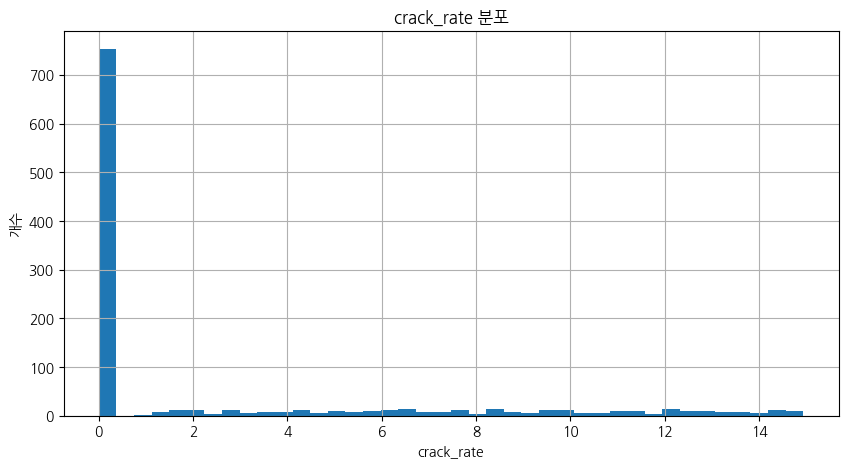

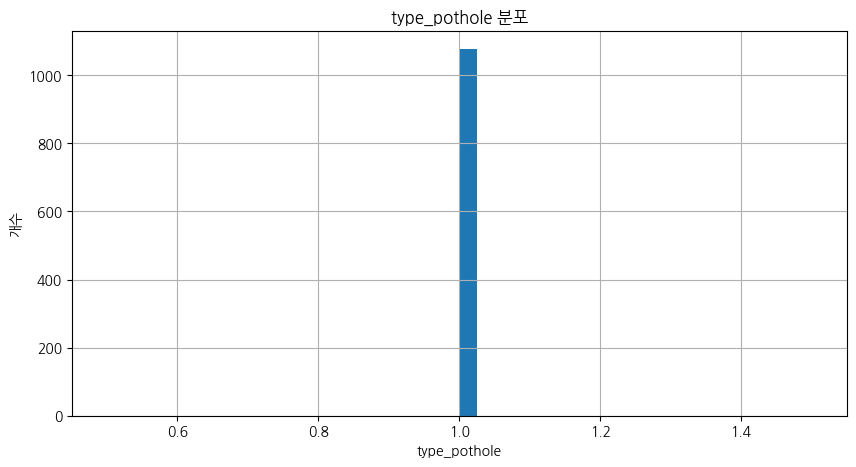

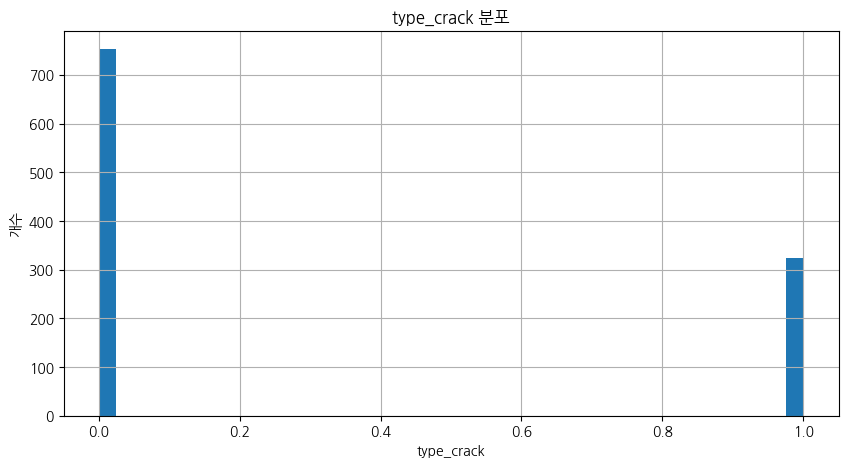

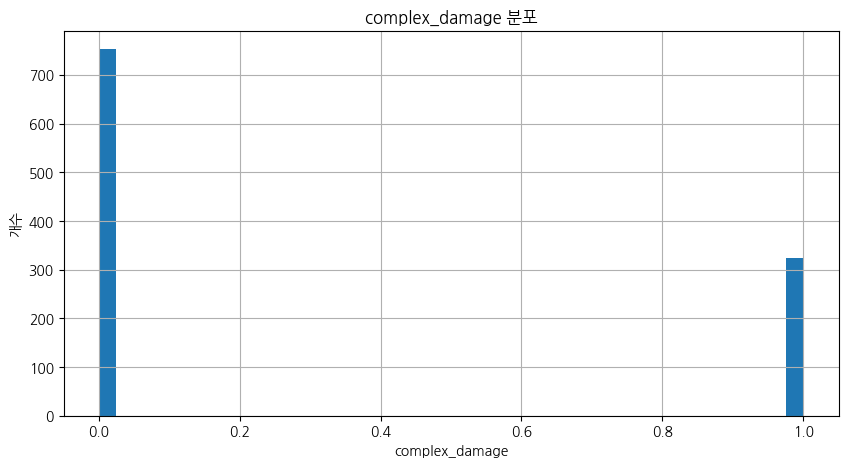


📌 10) 상관관계 Heatmap


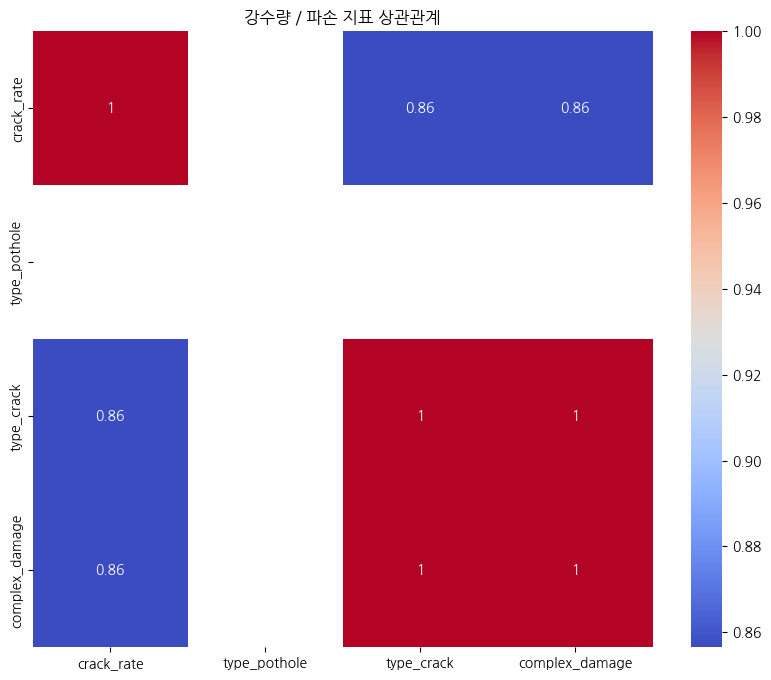


📌 11) 날짜 기반 시계열 분석
✔ 기준 날짜 컬럼: DATE


,DATE,crack_rate,type_pothole,type_crack,complex_damage
0,2024-01-19,1.523576,1.0,0.333333,0.333333
1,2024-01-23,0.000000,1.0,0.000000,0.000000
2,2024-01-31,0.000000,1.0,0.000000,0.000000
3,2024-02-06,0.000000,1.0,0.000000,0.000000
4,2024-02-13,0.000000,1.0,0.000000,0.000000


<Figure size 1200x500 with 0 Axes>

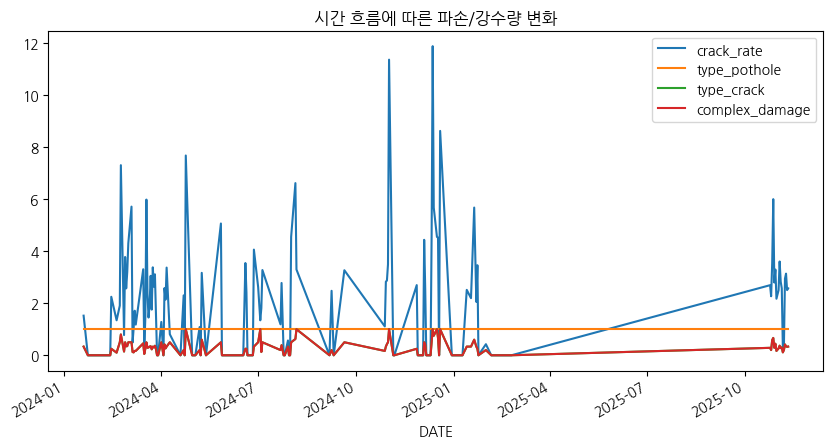


📌 12) 세그먼트 단위 통계 요약
✔ 세그먼트 기준 컬럼: DTCT_UID


,DTCT_UID,crack_rate,type_pothole,type_crack,complex_damage
0,RAD01_240119162357_441,0.0,1.0,0.0,0.0
1,RAD01_240119162610_0,0.0,1.0,0.0,0.0
2,RAD01_240119162611_0,0.0,1.0,0.0,0.0
3,RAD01_240119163618_0,0.0,1.0,0.0,0.0
4,RAD01_240119163629_608,0.0,1.0,0.0,0.0


In [10]:
# ======================================================================
# 🔧 0. 환경 설정 (한글 폰트 + 마이너스 깨짐 방지)
# ======================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 리눅스에서 기본 설치된 나눔폰트 자동 인식
font_candidates = ["NanumGothic", "NanumSquare", "NanumMyeongjo"]

available_fonts = fm.findSystemFonts()
selected_font = None

for f in font_candidates:
    if any(f in font_path for font_path in available_fonts):
        selected_font = f
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
else:
    plt.rcParams["font.family"] = "DejaVu Sans"  # fallback

plt.rcParams["axes.unicode_minus"] = False

print(f"✔ 적용된 폰트: {plt.rcParams['font.family']}")


# ======================================================================
# 🔧 1. 데이터 로드
# ======================================================================
import pandas as pd
import numpy as np

path = "/home/user/ai/AnKiHyeon/어프렌티스/road_data_v2.csv"

print("\n" + "=" * 80)
print("📌 1) 데이터 로드")
print("=" * 80)

try:
    df = pd.read_csv(path)
except:
    df = pd.read_csv(path, encoding="utf-8-sig")

print(f"✔ 데이터 크기: {df.shape}")
display(df.head())
print("\n✔ 컬럼 목록:")
print(df.columns.tolist())


# ======================================================================
# 🔧 2. 기본 정보
# ======================================================================
print("\n" + "=" * 80)
print("📌 2) DataFrame info")
print("=" * 80)
print(df.info())

print("\n📌 기초 통계량")
display(df.describe(include="all").T)


# ======================================================================
# 🔧 3. 결측치 확인
# ======================================================================
print("\n" + "=" * 80)
print("📌 3) 결측치 확인")
print("=" * 80)

nulls = df.isna().sum().sort_values(ascending=False)
display(nulls)


# ======================================================================
# 🔧 4. 중복 데이터 확인
# ======================================================================
print("\n" + "=" * 80)
print("📌 4) 중복 데이터 확인")
print("=" * 80)

dup_count = df.duplicated().sum()
print("✔ 중복 행 수:", dup_count)

if dup_count > 0:
    display(df[df.duplicated()].head())


# ======================================================================
# 🔧 5. 날짜 컬럼 자동 탐지 + 변환
# ======================================================================
print("\n" + "=" * 80)
print("📌 5) 날짜 컬럼 자동 감지 및 변환")
print("=" * 80)

date_cols = [c for c in df.columns if "date" in c.lower() or "날짜" in c.lower()]

print("✔ 감지된 날짜 컬럼:", date_cols)

for c in date_cols:
    try:
        df[c] = pd.to_datetime(df[c])
        print(f"✔ 날짜 변환 성공: {c}")
    except:
        print(f"❌ 날짜 변환 실패: {c}")


# ======================================================================
# 🔧 6. 파손 관련 컬럼 자동 탐지
# ======================================================================
print("\n" + "=" * 80)
print("📌 6) 파손 관련 컬럼 자동 탐지")
print("=" * 80)

damage_keys = ["pothole", "crack", "damage", "파손", "균열", "score"]
damage_cols = [c for c in df.columns if any(k in c.lower() for k in damage_keys)]

print("✔ 감지된 파손 컬럼:", damage_cols)


# ======================================================================
# 🔧 7. 강수량 관련 컬럼 자동 탐지
# ======================================================================
print("\n" + "=" * 80)
print("📌 7) 강수량 컬럼 자동 탐지")
print("=" * 80)

rain_keys = ["rain", "강수", "precip"]
rain_cols = [c for c in df.columns if any(k in c.lower() for k in rain_keys)]

print("✔ 감지된 강수량 컬럼:", rain_cols)


# ======================================================================
# 🔧 8. 세그먼트/도로 ID 탐지
# ======================================================================
print("\n" + "=" * 80)
print("📌 8) 세그먼트 / 구간 ID 컬럼 자동 탐지")
print("=" * 80)

seg_keys = ["segment", "seg", "road", "구간", "link", "id"]
seg_cols = [c for c in df.columns if any(k in c.lower() for k in seg_keys)]

print("✔ 감지된 세그먼트 후보:", seg_cols)


# ======================================================================
# 🔧 9. 파손 & 강수량 분포 시각화
# ======================================================================
print("\n" + "=" * 80)
print("📌 9) 파손/강수량 분포 시각화")
print("=" * 80)

for col in damage_cols + rain_cols:
    try:
        plt.figure()
        df[col].hist(bins=40)
        plt.title(f"{col} 분포")
        plt.xlabel(col)
        plt.ylabel("개수")
        plt.show()
    except:
        pass


# ======================================================================
# 🔧 10. 상관관계 Heatmap
# ======================================================================
print("\n" + "=" * 80)
print("📌 10) 상관관계 Heatmap")
print("=" * 80)

corr_cols = [c for c in (damage_cols + rain_cols) if df[c].dtype != "O"]

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("강수량 / 파손 지표 상관관계")
    plt.show()
else:
    print("⚠ 상관 분석 가능한 수치형 컬럼이 부족합니다.")


# ======================================================================
# 🔧 11. 시간 흐름 분석 (시계열)
# ======================================================================
print("\n" + "=" * 80)
print("📌 11) 날짜 기반 시계열 분석")
print("=" * 80)

if date_cols:
    dcol = date_cols[0]
    print(f"✔ 기준 날짜 컬럼: {dcol}")

    ts_cols = [c for c in corr_cols if c in df.columns]

    try:
        daily = df.groupby(dcol)[ts_cols].mean().reset_index()
        display(daily.head())

        plt.figure(figsize=(12, 5))
        daily.set_index(dcol)[ts_cols].plot()
        plt.title("시간 흐름에 따른 파손/강수량 변화")
        plt.show()
    except Exception as e:
        print("⚠ 시계열 분석 실패:", e)

else:
    print("⚠ 날짜 컬럼 없음 → 시계열 분석 생략")


# ======================================================================
# 🔧 12. 세그먼트 단위 통계 분석
# ======================================================================
print("\n" + "=" * 80)
print("📌 12) 세그먼트 단위 통계 요약")
print("=" * 80)

if seg_cols:
    seg_base = seg_cols[0]
    print(f"✔ 세그먼트 기준 컬럼: {seg_base}")

    summary_cols = [c for c in damage_cols + rain_cols if c in df.columns]
    seg_summary = df.groupby(seg_base)[summary_cols].mean().reset_index()

    display(seg_summary.head())
else:
    print("⚠ 세그먼트 컬럼 없음 → 구간 기반 통계 생략")

▶ 모델 학습 시작...
▶ 모델 학습 완료.

[분류 리포트]
              precision    recall  f1-score   support

           0      0.673     0.722     0.696       151
           1      0.222     0.185     0.202        65

    accuracy                          0.560       216
   macro avg      0.448     0.453     0.449       216
weighted avg      0.537     0.560     0.548       216

[ROC-AUC] 0.4706062149770759


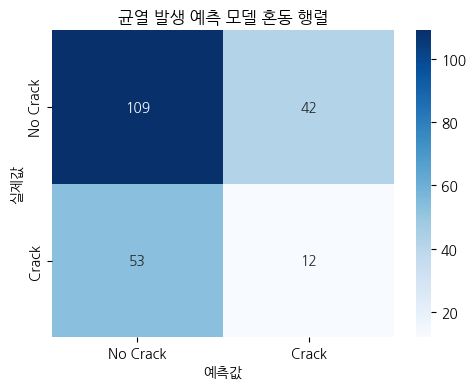

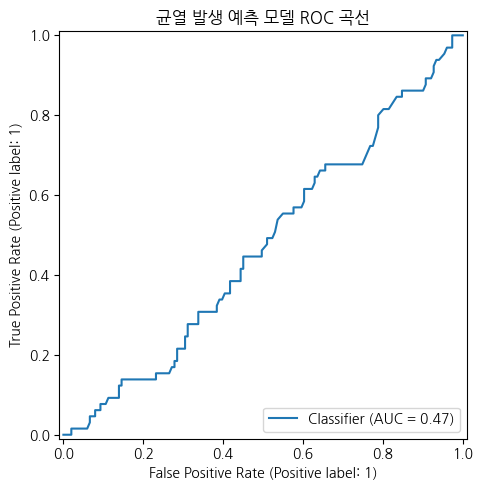

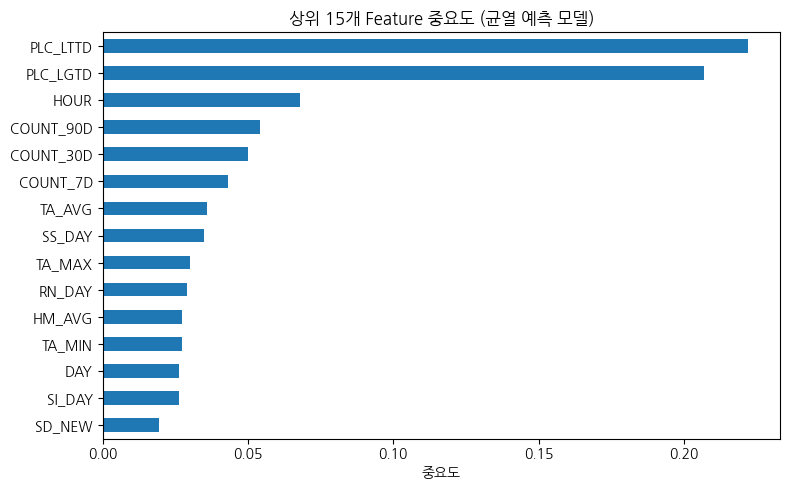

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)

# 1) 데이터 로드 (이미 로드되어 있다면 생략)
path = "/home/user/ai/AnKiHyeon/어프렌티스/road_data_v2.csv"
df = pd.read_csv(path)

# 2) 날짜 변환
df["DATE"] = pd.to_datetime(df["DATE"])

# 3) -9 결측치 코드 처리 (추측입니다: RN_DUR, SD_* 컬럼은 -9가 결측치일 가능성이 큼)
missing_code_cols = ["RN_DUR", "SD_DAY", "SD_NEW", "SD_MAX"]
for c in missing_code_cols:
    if c in df.columns:
        df[c] = df[c].replace(-9, np.nan)

# 4) 타깃 설정 (균열 여부 예측)
target_col = "type_crack"

# 5) 사용할 Feature 선택
feature_cols = [
    "PLC_LTTD",
    "PLC_LGTD",
    "YEAR",
    "MONTH",
    "DAY",
    "HOUR",
    "WEEKDAY",
    "COMMUTE",
    "COUNT_7D",
    "COUNT_30D",
    "COUNT_90D",
    "TA_AVG",
    "TA_MAX",
    "TA_MIN",
    "RN_DAY",
    "RN_DUR",
    "RN_D99",
    "SD_DAY",
    "SD_NEW",
    "SD_MAX",
    "HM_AVG",
    "SI_DAY",
    "SS_DAY",
    "SEASON",
]

feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy()
y = df[target_col].copy()

# 6) 범주형(계절) One-hot 인코딩
if "SEASON" in X.columns:
    X = pd.get_dummies(X, columns=["SEASON"], drop_first=True)

# 7) 숫자형 결측치 -> 중앙값 대체
num_cols = X.select_dtypes(include=[np.number]).columns
for c in num_cols:
    X[c] = X[c].fillna(X[c].median())

# 8) train / test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 9) 랜덤포레스트 분류기 (불균형 대응 위해 class_weight="balanced")
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

print("▶ 모델 학습 시작...")
model.fit(X_train, y_train)
print("▶ 모델 학습 완료.")

# 10) 예측 및 성능 지표
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n[분류 리포트]")
print(classification_report(y_test, y_pred, digits=3))

print("[ROC-AUC]", roc_auc_score(y_test, y_proba))

# 11) 혼동 행렬 시각화 (보고서용)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Crack", "Crack"],
    yticklabels=["No Crack", "Crack"],
)
plt.xlabel("예측값")
plt.ylabel("실제값")
plt.title("균열 발생 예측 모델 혼동 행렬")
plt.tight_layout()
plt.show()

# 12) ROC 곡선 시각화 (보고서용)
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("균열 발생 예측 모델 ROC 곡선")
plt.tight_layout()
plt.show()

# 13) Feature Importance (보고서용)
importances = pd.Series(model.feature_importances_, index=X.columns)
imp_top = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
imp_top.sort_values().plot(kind="barh")
plt.xlabel("중요도")
plt.title("상위 15개 Feature 중요도 (균열 예측 모델)")
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# ======================================================================
# 1. CSV 경로
# ======================================================================
road_csv_path = "/home/user/ai/AnKiHyeon/어프렌티스/대전광역시_도로중심선_현황/대전광역시_도로중심선 현황_20221215.csv"

# ======================================================================
# 2. 인코딩 자동 탐색 후 CSV 로드
# ======================================================================
encodings = ["utf-8-sig", "cp949", "euc-kr", "latin1"]
df_road = None

print("📌 [1] CSV 인코딩 자동 로드 시도\n")

for enc in encodings:
    try:
        df_road = pd.read_csv(road_csv_path, encoding=enc)
        print(f"✔ 로드 성공 — encoding={enc}")
        break
    except Exception as e:
        print(f"✖ 로드 실패 — encoding={enc} → {e}")

if df_road is None:
    raise RuntimeError("CSV를 어떤 인코딩으로도 읽지 못했습니다.")

# ======================================================================
# 3. 컬럼명 출력
# ======================================================================
print("\n📌 [2] CSV 컬럼 목록")
print(df_road.columns.tolist())

# ======================================================================
# 4. WKT 컬럼 자동 탐색
# ======================================================================
print("\n📌 [3] WKT 컬럼 자동 탐색 결과")

wkt_col = None
for col in df_road.columns:
    if df_road[col].dtype == object:
        val = df_road[col].dropna().astype(str).head(1).iloc[0]
        if "LINESTRING" in val or "MULTI" in val or "POINT" in val or "POLYGON" in val:
            wkt_col = col
            print(f"→ 탐지됨: {col}")
            break

if wkt_col is None:
    print("❌ WKT 컬럼을 찾지 못했습니다. 직접 알려주세요.")
else:
    print(f"✔ 선택된 WKT 컬럼: {wkt_col}")

# ======================================================================
# 5. WKT 내용 샘플 출력
# ======================================================================
print("\n📌 [4] WKT 데이터 샘플 30개 출력\n")

sample_wkts = df_road[wkt_col].dropna().astype(str).head(30).tolist()

for i, w in enumerate(sample_wkts):
    print(f"[{i}] {w}\n")

print("📌 끝 — 위 출력값을 ChatGPT에게 보내주세요.")

📌 [1] CSV 인코딩 자동 로드 시도

✖ 로드 실패 — encoding=utf-8-sig → 'utf-8' codec can't decode byte 0xc1 in position 0: invalid start byte
✔ 로드 성공 — encoding=cp949

📌 [2] CSV 컬럼 목록
['지리정보(WKT)', '도로구간번호', '지형지물부호', '행정읍면동', '도엽번호', '도로폭원', '대장초기화']

📌 [3] WKT 컬럼 자동 탐색 결과
→ 탐지됨: 지리정보(WKT)
✔ 선택된 WKT 컬럼: 지리정보(WKT)

📌 [4] WKT 데이터 샘플 30개 출력

[0] MULTILINESTRING ((225418.460148012 405119.704992344,225419.153980267 405121.461102174))

[1] MULTILINESTRING ((225419.153980267 405121.461102174,225421.368970729 405127.071062465,225421.83303882 405129.965061354,225421.903095662 405133.255993561,225421.309954113 405137.733999944,225420.181111527 405142.925140612,225417.812044 405153.450106911,225415.89001453 405165.903982194,225415.554121304 405172.565024618,225415.8951109 405177.24813403,225417.279099054 405181.278950845,225419.276970744 405183.442956042,225421.700992309 405185.146967439,225424.739141023 405185.790104192,225432.887023209 405186.122064081,225437.143014917 405186.351109202,225439.296033135 405186

In [21]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, MultiLineString, box
import numpy as np
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings("ignore")

# ============================================================================
# 1. 입력 데이터 경로
# ============================================================================
road_csv_path = "/home/user/ai/AnKiHyeon/어프렌티스/대전광역시_도로중심선_현황/대전광역시_도로중심선 현황_20221215.csv"
pothole_csv_path = "/home/user/ai/AnKiHyeon/어프렌티스/road_data_v2.csv"

# ============================================================================
# 2. 도로 중심선 CSV 로드 (인코딩 자동 감지)
# ============================================================================
encodings = ["utf-8-sig", "cp949", "euc-kr", "latin1"]
df_road = None

for enc in encodings:
    try:
        df_road = pd.read_csv(road_csv_path, encoding=enc)
        print(f"✔ 도로 CSV 로드 성공 — encoding={enc}")
        break
    except Exception:
        print(f"✖ 로드 실패 — encoding={enc}")

if df_road is None:
    raise RuntimeError("도로 CSV를 읽지 못했습니다.")

# WKT 컬럼 이름
wkt_col = "지리정보(WKT)"

# ============================================================================
# 3. 도로 중심선 → GeoDataFrame 변환 (EPSG:5186 로 설정)
# ============================================================================
gdf_road = gpd.GeoDataFrame(
    df_road,
    geometry=gpd.GeoSeries.from_wkt(df_road[wkt_col]),
    crs="EPSG:5186",
)
print("도로 중심선 총 개수:", len(gdf_road))

# ============================================================================
# 4. MULTILINESTRING → LINESTRING 조각 분해
# ============================================================================
def explode_multilinestring(geom):
    """MULTILINESTRING → 개별 LINESTRING 리스트."""
    if geom.geom_type == "MultiLineString":
        return list(geom.geoms)
    elif geom.geom_type == "LineString":
        return [geom]
    return []

expanded_geoms = []
for geom in gdf_road.geometry:
    expanded_geoms.extend(explode_multilinestring(geom))

gdf_road_ex = gpd.GeoDataFrame(geometry=expanded_geoms, crs="EPSG:5186")
print("LINESTRING 개수:", len(gdf_road_ex))

# ============================================================================
# 5. 포트홀 데이터 로드 → GeoDataFrame(EPSG:4326)
# ============================================================================
df_pothole = pd.read_csv(pothole_csv_path)

gdf_pothole = gpd.GeoDataFrame(
    df_pothole,
    geometry=gpd.points_from_xy(df_pothole["PLC_LGTD"], df_pothole["PLC_LTTD"]),
    crs="EPSG:4326",
)

# 포트홀 좌표계 → EPSG:5186 로 변환
gdf_pothole_5186 = gdf_pothole.to_crs("EPSG:5186")
print("포트홀 개수:", len(gdf_pothole_5186))

# ============================================================================
# 6. 도로 중심선 잘라내기 (포트홀 주변 BOX 기준)
# ============================================================================
minx, miny, maxx, maxy = gdf_pothole_5186.total_bounds
margin = 5000  # 5km 확장 영역
bbox_geom = box(minx - margin, miny - margin, maxx + margin, maxy + margin)

bbox = gpd.GeoDataFrame(geometry=[bbox_geom], crs="EPSG:5186")

gdf_road_clip = gpd.overlay(gdf_road_ex, bbox, how="intersection")
print("클리핑된 도로 개수:", len(gdf_road_clip))

# ============================================================================
# 7. 도로 중심선에서 일정 간격으로 포인트 샘플링
# ============================================================================
STEP_M = 20  # 20m 간격

def sample_points(line, step=20):
    """LINESTRING에서 일정 간격으로 좌표 샘플링"""
    pts = []
    if line.length == 0:
        return pts
    distances = np.arange(0, line.length, step)
    for d in distances:
        pts.append(line.interpolate(d))
    return pts

sampled_points = []
for geom in gdf_road_clip.geometry:
    sampled_points.extend(sample_points(geom, STEP_M))

gdf_track = gpd.GeoDataFrame(geometry=sampled_points, crs="EPSG:5186")
print("샘플링된 포인트 개수:", len(gdf_track))

# ============================================================================
# 8. 포트홀 주변 50m 버퍼 생성 → NEG 샘플 선택
# ============================================================================
BUFFER_M = 50

gdf_pothole_5186["buffer"] = gdf_pothole_5186.buffer(BUFFER_M)
buffer_union = gdf_pothole_5186["buffer"].unary_union

# 거리 계산
dists = gdf_track.geometry.apply(lambda p: p.distance(buffer_union))

# NEG 샘플 = 50m 이상 떨어진 포인트
gdf_neg = gdf_track[dists > BUFFER_M].copy()
print("NEG 샘플 개수:", len(gdf_neg))

# WGS84로 변환(Folium 표시용)
gdf_neg_wgs = gdf_neg.to_crs("EPSG:4326")
gdf_pothole_wgs = gdf_pothole.to_crs("EPSG:4326")

# ============================================================================
# 9. Folium 지도 시각화
# ============================================================================
center_lat = gdf_pothole_wgs.geometry.y.mean()
center_lng = gdf_pothole_wgs.geometry.x.mean()

m = folium.Map(location=[center_lat, center_lng], zoom_start=12)

# 포트홀(Positive)
pos_cluster = MarkerCluster().add_to(m)
for idx, row in gdf_pothole_wgs.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color="red",
        fill=True,
        fill_opacity=0.7,
    ).add_to(pos_cluster)

# NEG 포인트
neg_cluster = MarkerCluster().add_to(m)
for idx, row in gdf_neg_wgs.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color="blue",
        fill=True,
        fill_opacity=0.6,
    ).add_to(neg_cluster)

m.save("pothole_negative_sampling_map.html")
print("▶ Folium 지도 저장 완료: pothole_negative_sampling_map.html")


✖ 로드 실패 — encoding=utf-8-sig
✔ 도로 CSV 로드 성공 — encoding=cp949
도로 중심선 총 개수: 135603
LINESTRING 개수: 135630
포트홀 개수: 1077
클리핑된 도로 개수: 134344
샘플링된 포인트 개수: 313330
NEG 샘플 개수: 291174
▶ Folium 지도 저장 완료: pothole_negative_sampling_map.html


=== 데이터 크기 === (1077, 31)
                    DTCT_UID   PLC_LTTD    PLC_LGTD            ROAD_INFO  \
0    gnsoft1_251106093349_24  36.390977  127.407906  대전광역시 유성구 문지동 661-3   
1    gnsoft1_251106093431_32  36.390877  127.407925  대전광역시 유성구 문지동 661-3   
2    gnsoft1_251106194824_90  36.350716  127.368103     대전광역시 서구 갈마동 690   
3  gnsoft2_251025113907_2278  36.337395  127.412706    대전광역시 중구 중촌동 18-6   
4  gnsoft2_251025120737_5711  36.343555  127.407201  대전광역시 중구 중촌동 266-11   

   YEAR  MONTH  DAY  HOUR  WEEKDAY  SEASON  ...  TA_MIN  RN_DAY  RN_DUR  \
0  2025     11    6     9        3  autumn  ...    1438    2.13    -9.0   
1  2025     11    6     9        3  autumn  ...    1438    2.13    -9.0   
2  2025     11    6    19        3  autumn  ...    1438    2.13    -9.0   
3  2025     10   25    11        5  autumn  ...    1408    1.57    -9.0   
4  2025     10   25    12        5  autumn  ...    1408    1.57    -9.0   

   RN_D99  SD_DAY SD_NEW  SD_MAX  HM_AVG  SI_DAY  SS_DAY  
0    12

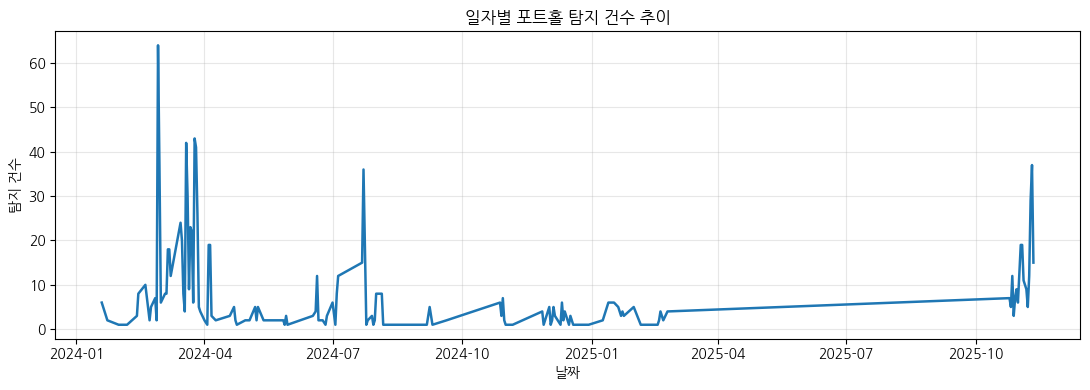

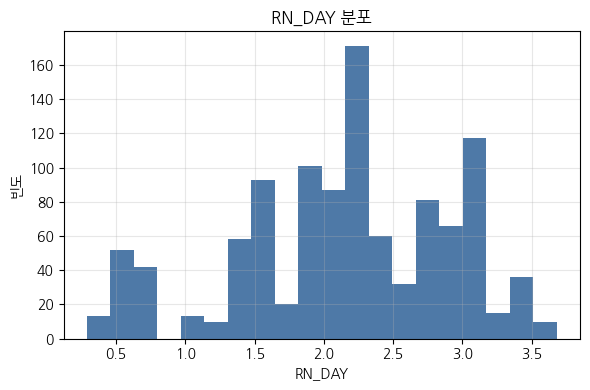

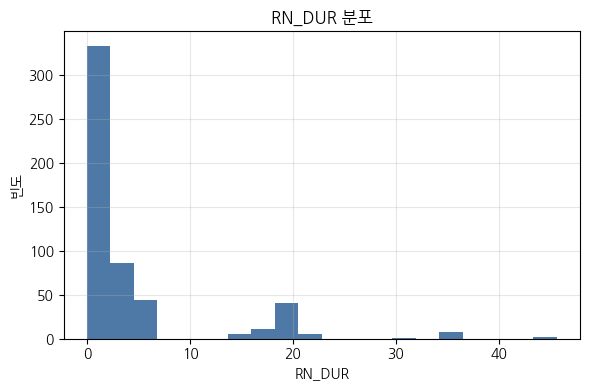

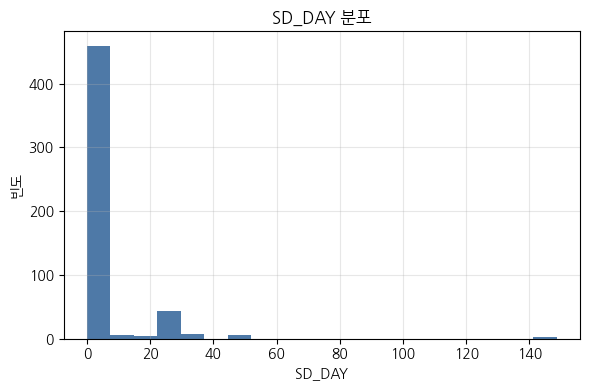

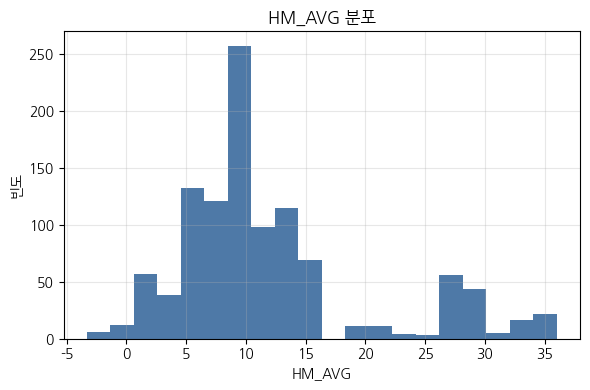

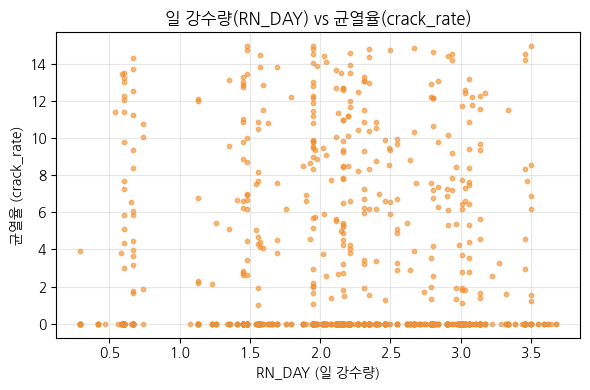

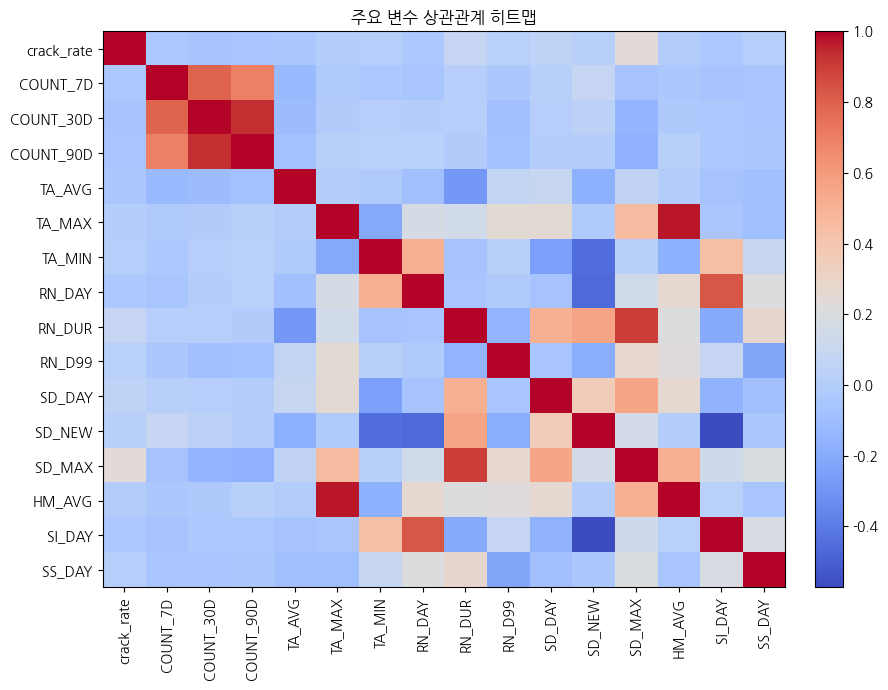

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# ------------------------------------------
# 1) 폰트 설정 (Nanum Gothic)
# ------------------------------------------
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
try:
    font_manager.fontManager.addfont(font_path)
    rcParams["font.family"] = "NanumGothic"
except:
    rcParams["font.family"] = "DejaVu Sans"
rcParams["axes.unicode_minus"] = False

# ------------------------------------------
# 2) 데이터 로드
# ------------------------------------------
DATA_PATH = "/home/user/ai/AnKiHyeon/어프렌티스/road_data_v2.csv"
df = pd.read_csv(DATA_PATH)

print("=== 데이터 크기 ===", df.shape)
print(df.head(), "\n")

# ------------------------------------------
# 3) 날짜 컬럼 처리
# ------------------------------------------
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE")

# ------------------------------------------
# 4) 로그 출력 (보고서용)
# ------------------------------------------
n_rows = len(df)
n_days = df["DATE"].nunique()
period_start = df["DATE"].min().date()
period_end = df["DATE"].max().date()

print("=== 데이터 로그 요약 ===")
print(f"· 전체 포트홀 탐지 건수: {n_rows:,} 개")
print(f"· 관측된 날짜 수: {n_days} 일")
print(f"· 관측 기간: {period_start} ~ {period_end}")
print(f"· 도로 구간 개수(ROAD_INFO 기준): {df['ROAD_INFO'].nunique()} 개")
print()

# ------------------------------------------
# 5) 일자별 포트홀 탐지 추이
# ------------------------------------------
daily_counts = df.groupby("DATE")["DTCT_UID"].count()

plt.figure(figsize=(11, 4))
plt.plot(daily_counts.index, daily_counts.values, linewidth=1.8)
plt.title("일자별 포트홀 탐지 건수 추이")
plt.xlabel("날짜")
plt.ylabel("탐지 건수")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------
# 6) 강수량/기상 변수 분포 그래프
# ------------------------------------------
vars_dist = ["RN_DAY", "RN_DUR", "SD_DAY", "HM_AVG"]
vars_dist = [v for v in vars_dist if v in df.columns]

for v in vars_dist:
    data = df[v].replace(-9.0, np.nan).dropna()
    if len(data) == 0:
        continue
    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=20, color="#4E79A7")
    plt.title(f"{v} 분포")
    plt.xlabel(v)
    plt.ylabel("빈도")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------------------------
# 7) 강수량 vs 균열율
# ------------------------------------------
if "RN_DAY" in df.columns and "crack_rate" in df.columns:
    tmp = df[["RN_DAY", "crack_rate"]].replace(-9.0, np.nan).dropna()

    plt.figure(figsize=(6, 4))
    plt.scatter(tmp["RN_DAY"], tmp["crack_rate"], s=10, alpha=0.6, color="#F28E2B")
    plt.title("일 강수량(RN_DAY) vs 균열율(crack_rate)")
    plt.xlabel("RN_DAY (일 강수량)")
    plt.ylabel("균열율 (crack_rate)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------------------------
# 8) 상관관계 히트맵
# ------------------------------------------
corr_cols = [
    "crack_rate",
    "COUNT_7D",
    "COUNT_30D",
    "COUNT_90D",
    "TA_AVG",
    "TA_MAX",
    "TA_MIN",
    "RN_DAY",
    "RN_DUR",
    "RN_D99",
    "SD_DAY",
    "SD_NEW",
    "SD_MAX",
    "HM_AVG",
    "SI_DAY",
    "SS_DAY",
]
corr_cols = [c for c in corr_cols if c in df.columns]

df_corr = df[corr_cols].replace(-9.0, np.nan)
corr = df_corr.corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(fraction=0.045, pad=0.04)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("주요 변수 상관관계 히트맵")
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

road_csv = "/home/user/ai/AnKiHyeon/어프렌티스/대전광역시_도로중심선_현황/대전광역시_도로중심선 현황_20221215.csv"

# 1) CSV 인코딩 탐색
df_road = None
for enc in ["utf-8-sig", "cp949", "euc-kr"]:
    try:
        df_road = pd.read_csv(road_csv, encoding=enc)
        print(f"✔ CSV 로드 성공: encoding={enc}")
        break
    except Exception as e:
        print(f"✖ CSV 로드 실패: encoding={enc}, {e}")

# 2) WKT 컬럼 탐색
wkt_col_candidates = [c for c in df_road.columns if "WKT" in c or "지리정보" in c]
wkt_col = wkt_col_candidates[0]
print("선택된 WKT 컬럼:", wkt_col)

# 3) WKT → geometry 변환 (오류 무시)
geometry_list = []
for w in df_road[wkt_col]:
    try:
        geometry_list.append(wkt.loads(w))
    except:
        geometry_list.append(None)

gdf_road = gpd.GeoDataFrame(df_road, geometry=geometry_list, crs="EPSG:5186")

# 4) geometry 없는 행 제거
before = len(gdf_road)
gdf_road = gdf_road[gdf_road.geometry.notna()].copy()
print(f"유효 LineString 개수: {before} → {len(gdf_road)}")

# 5) 타입 확인
print("geometry 타입 샘플:", type(gdf_road.geometry.iloc[0]))

✖ CSV 로드 실패: encoding=utf-8-sig, 'utf-8' codec can't decode byte 0xc1 in position 0: invalid start byte
✔ CSV 로드 성공: encoding=cp949
선택된 WKT 컬럼: 지리정보(WKT)
유효 LineString 개수: 135603 → 135603
geometry 타입 샘플: <class 'shapely.geometry.multilinestring.MultiLineString'>


POS 개수: 1077
✖ CSV 로드 실패 (utf-8-sig): 'utf-8' codec can't decode byte 0xc1 in position 0: invalid start byte
✔ 도로 CSV 로드 성공: encoding=cp949
선택된 WKT 컬럼: 지리정보(WKT)
유효 도로 수: 135603 → 135603
클리핑된 도로 개수: 134317
도로 샘플링 중...


100%|██████████| 134317/134317 [00:03<00:00, 38941.25it/s]


샘플링된 도로 포인트 수: 189367


/tmp/ipykernel_1716461/3793925312.py:124: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_union = gdf_pos["buffer50"].unary_union


최종 NEG 후보 수: 175397
최종 데이터셋 크기: (176474, 25)
✔ 최종 데이터셋 저장 완료: /home/user/ai/AnKiHyeon/어프렌티스/final_pothole_dataset.csv


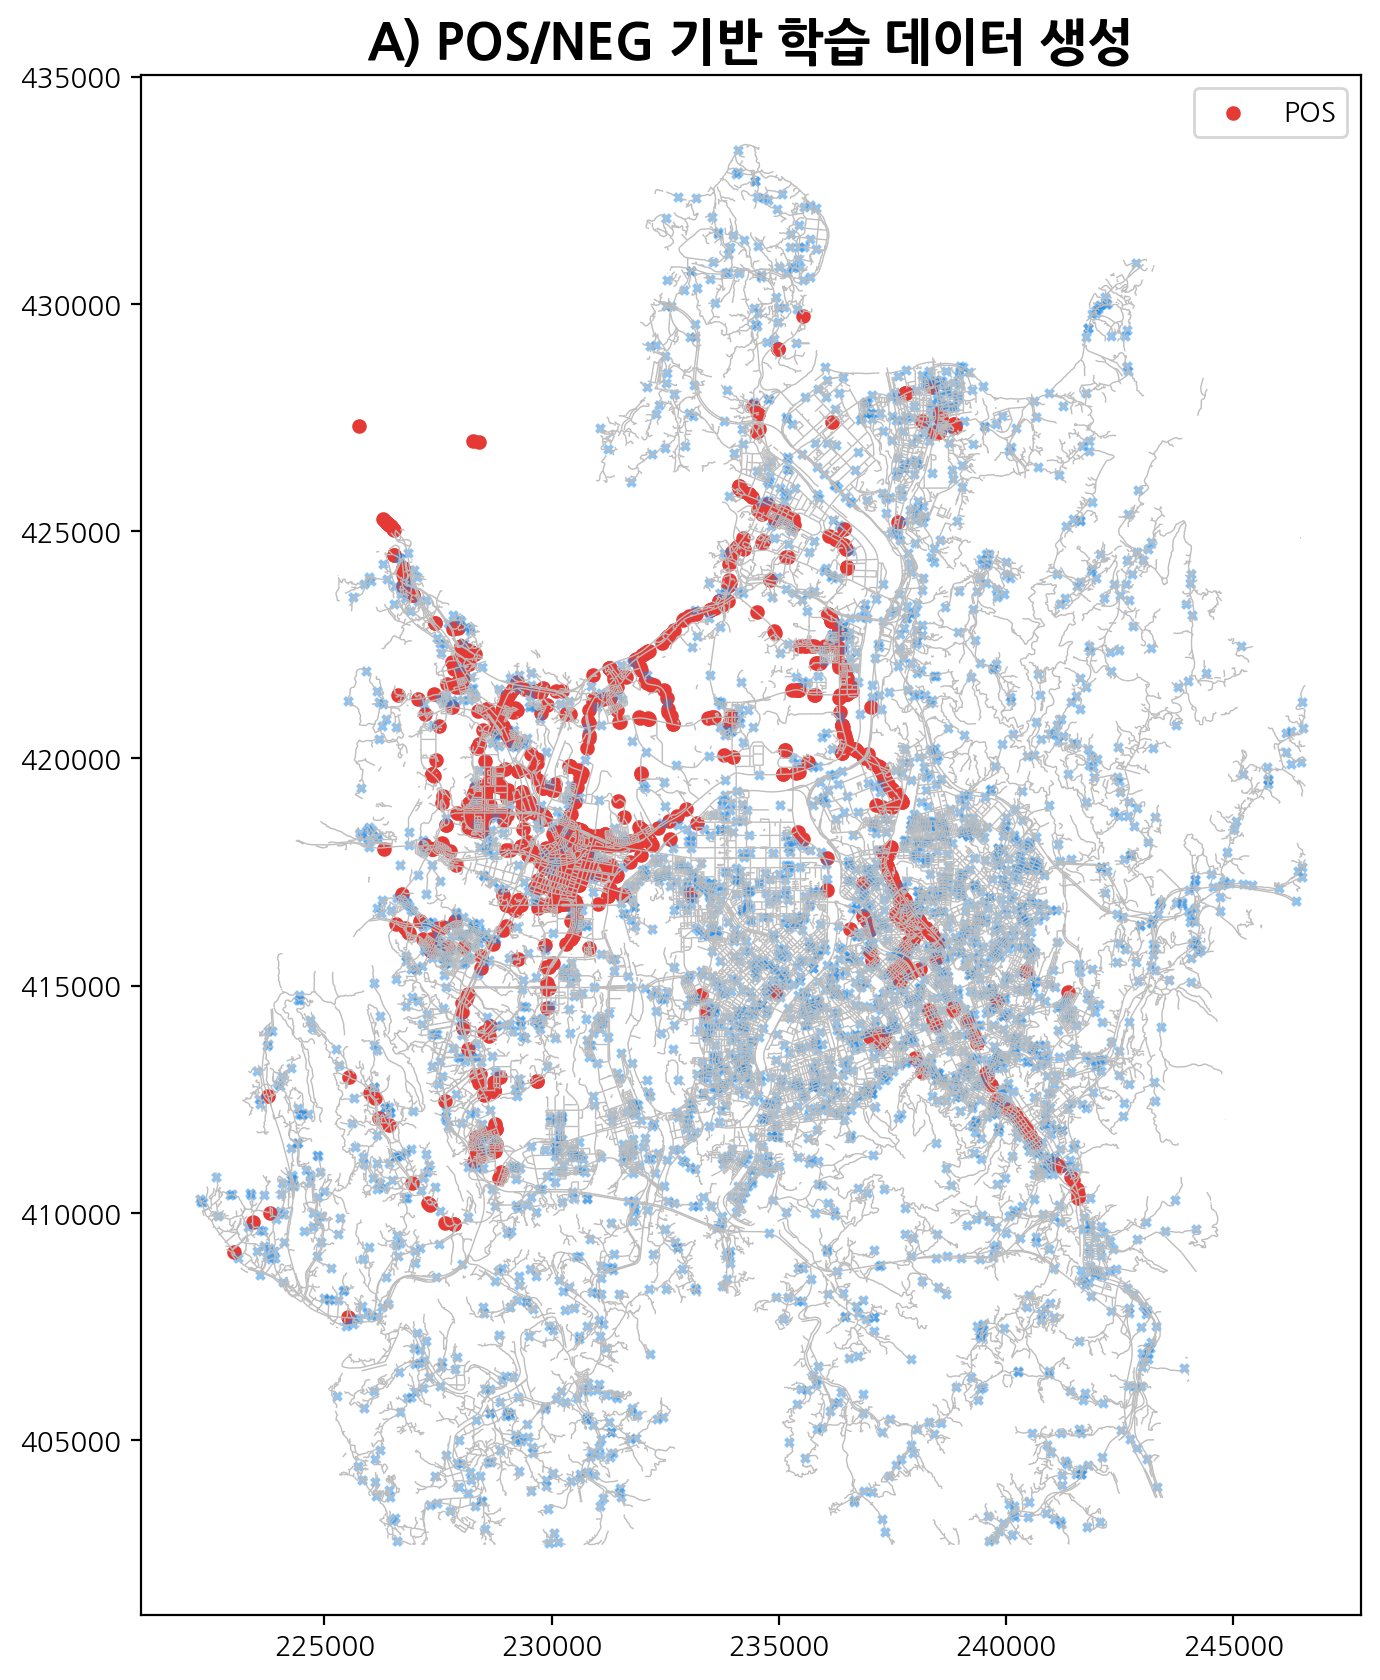

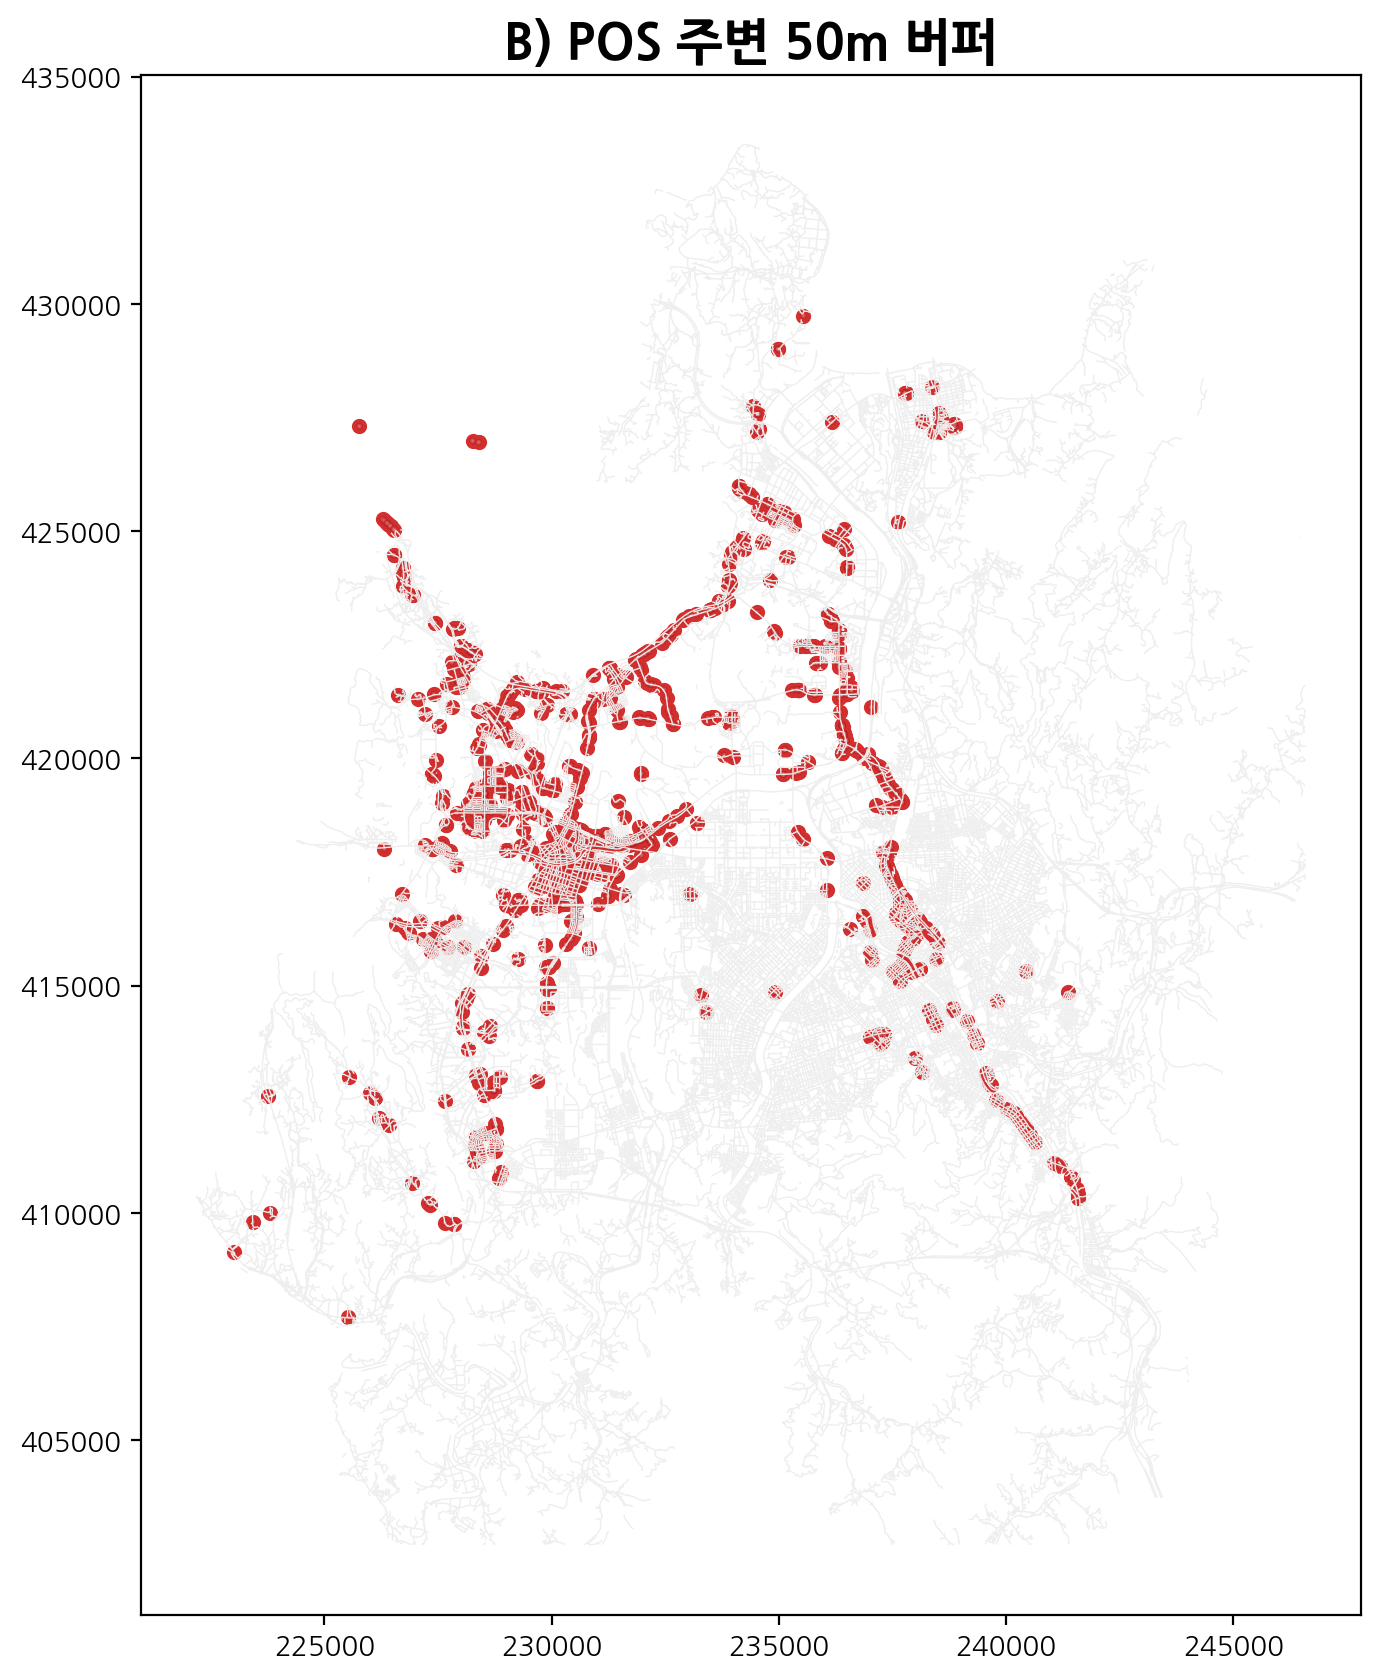

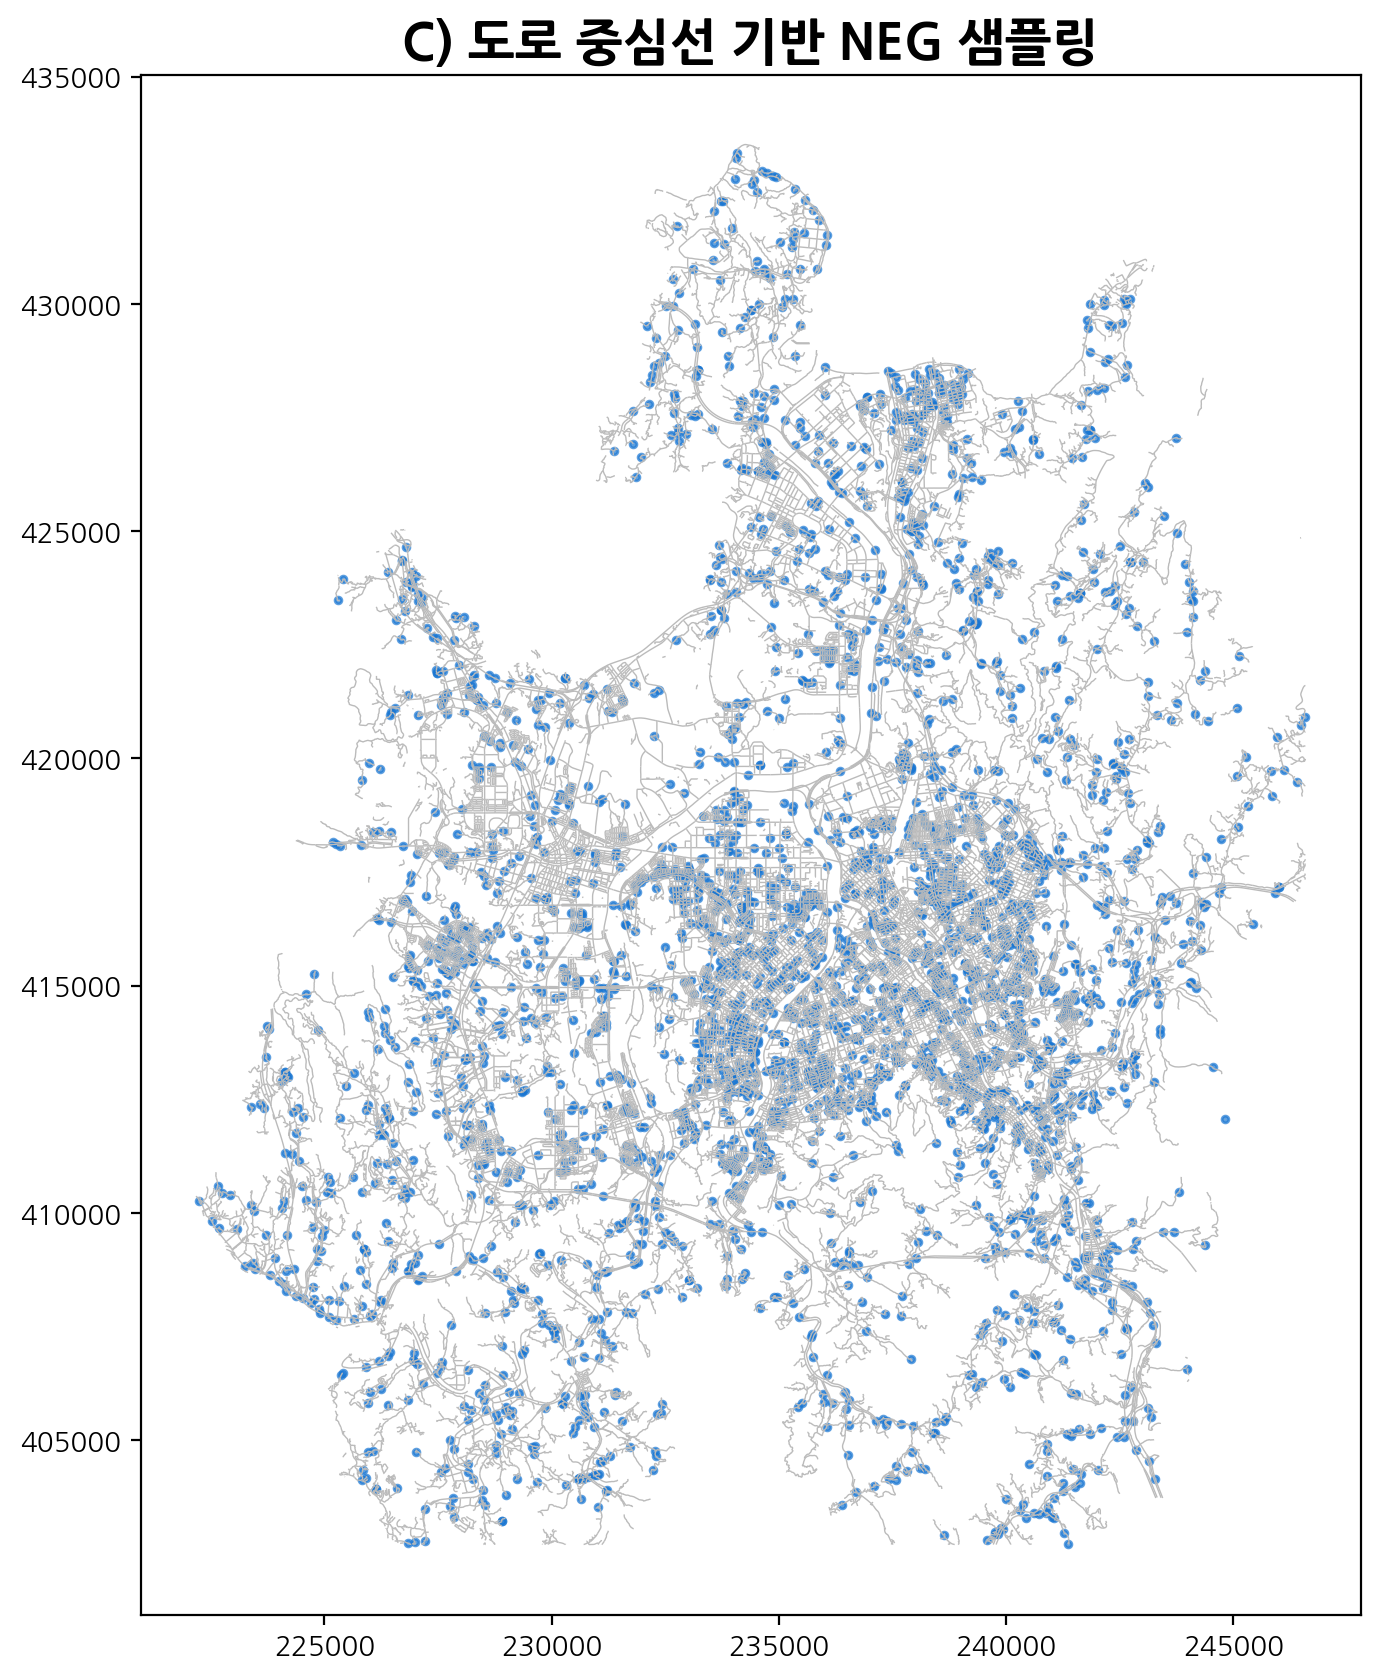

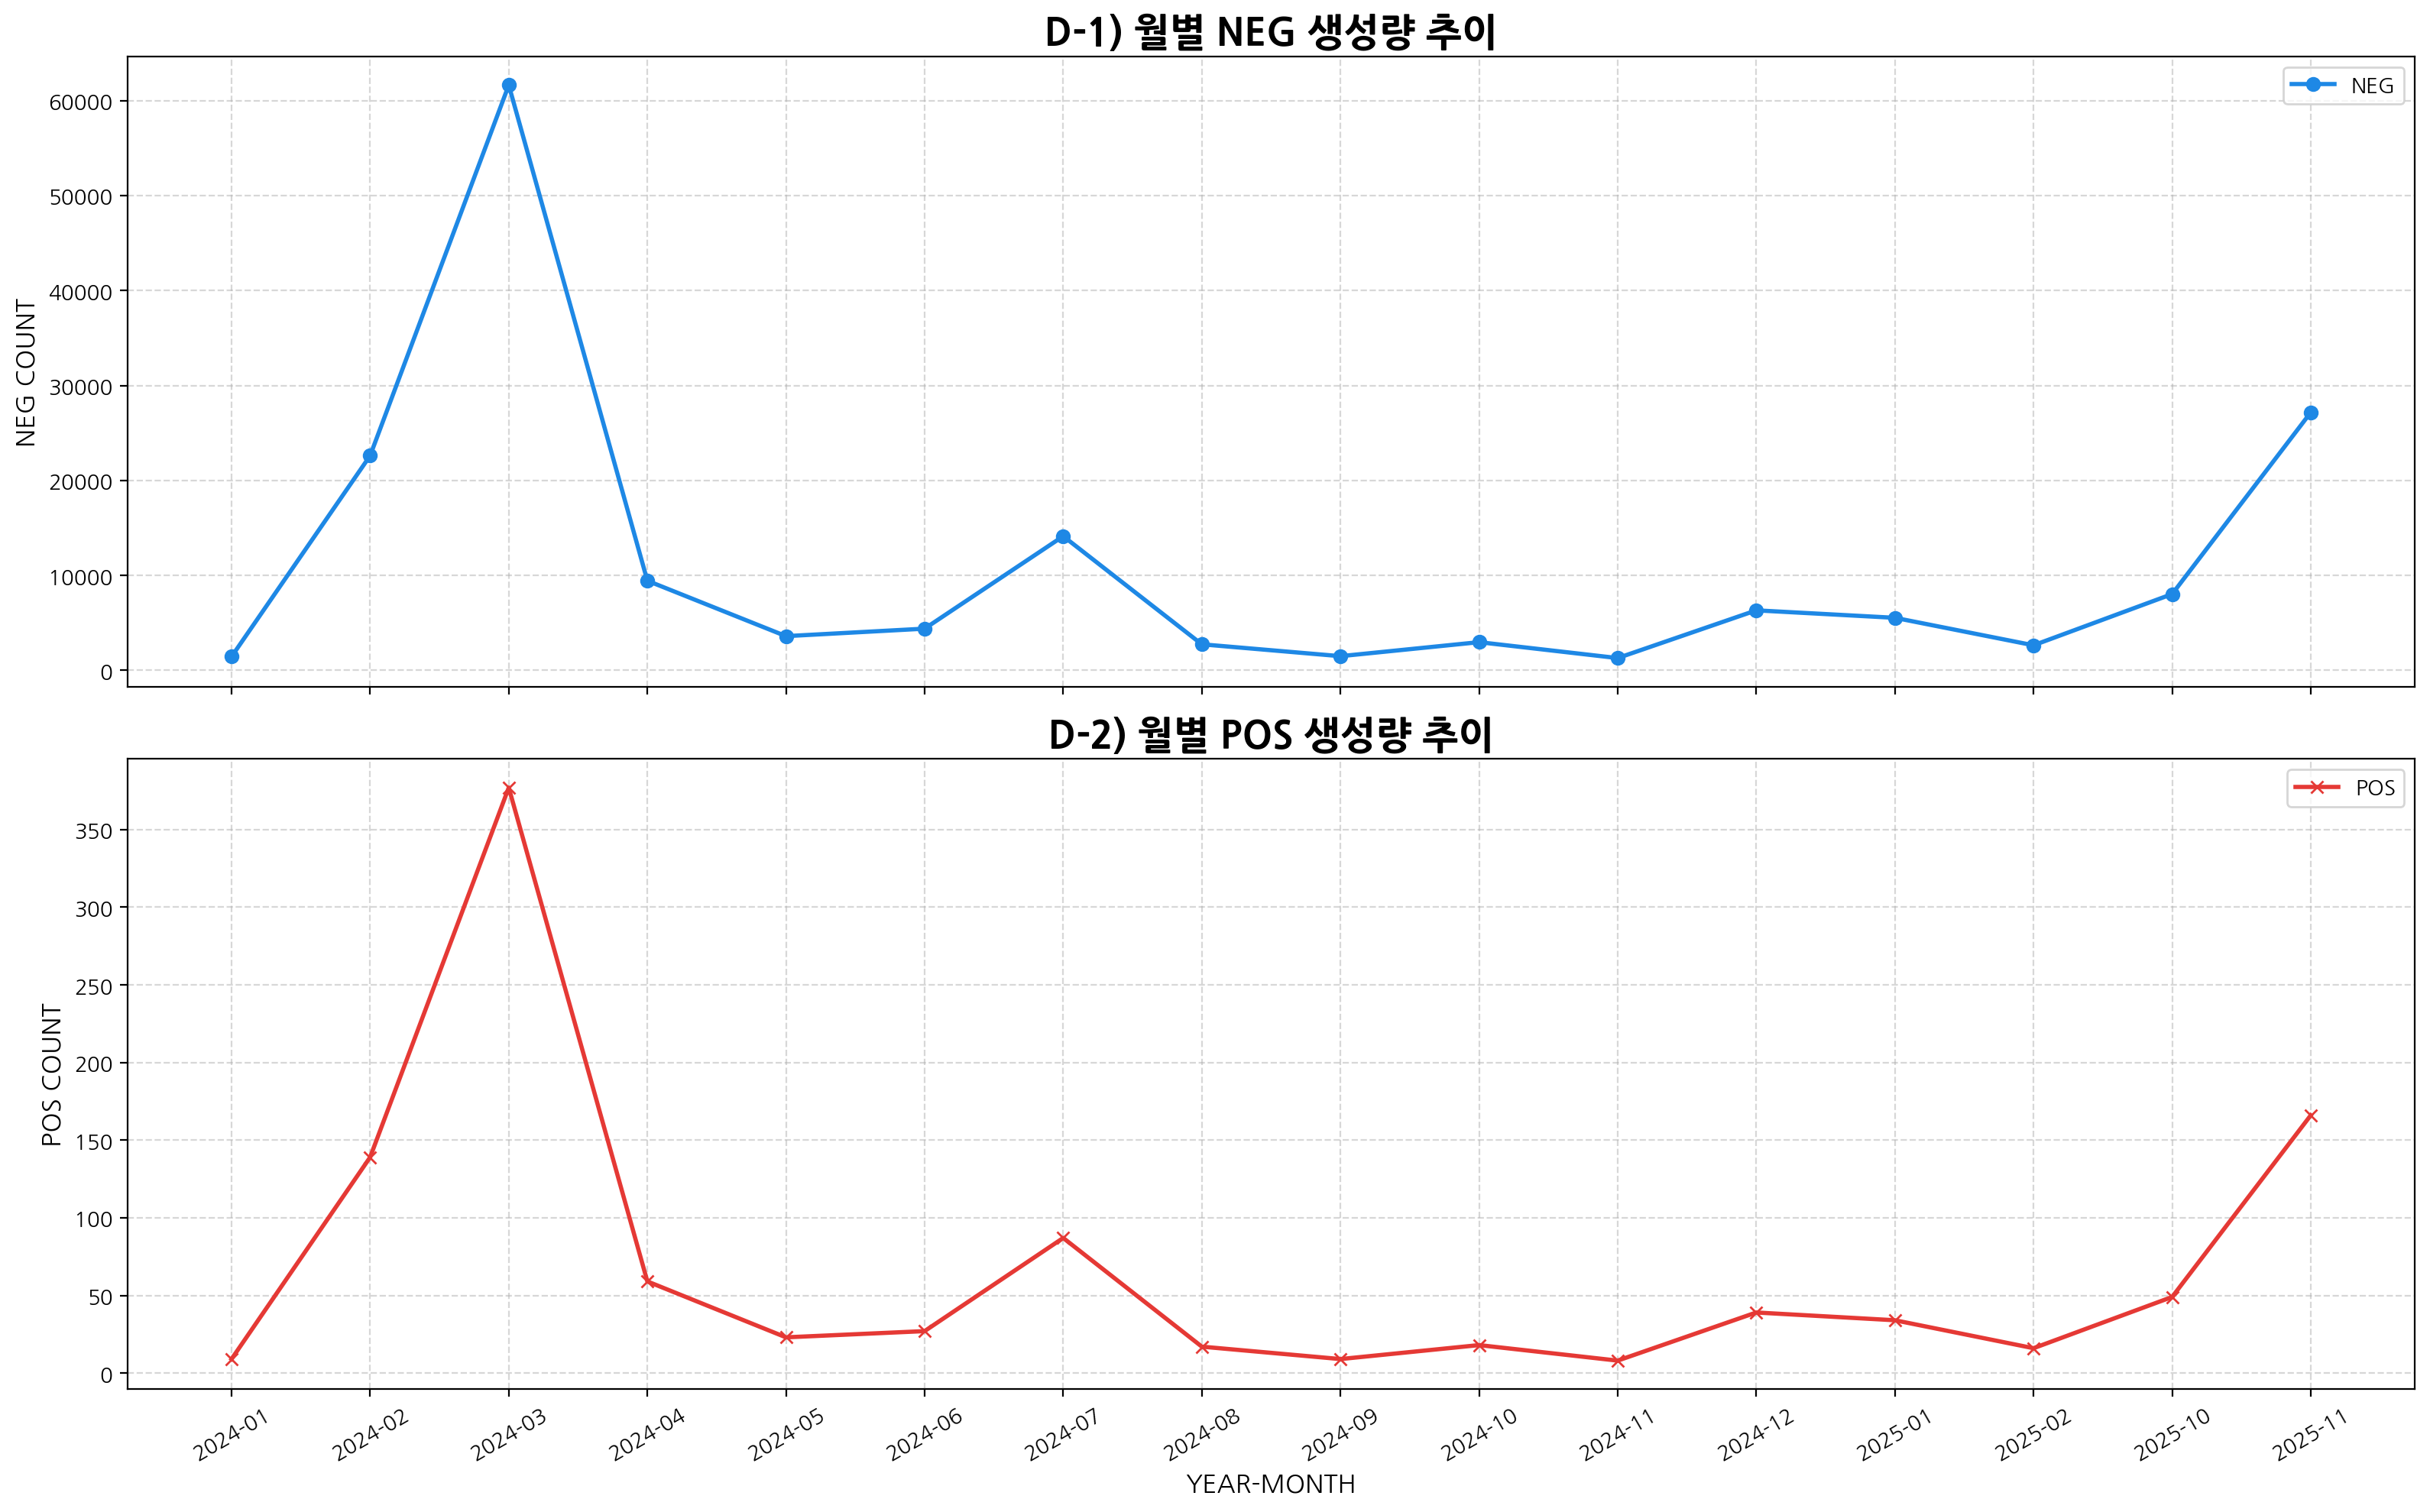

In [ ]:
# ===============================================================
# 0. 기본 설정
# ===============================================================
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box, LineString, MultiLineString
from shapely import wkt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


# ===============================================================
# 1. 포트홀 POS 데이터 로드
# ===============================================================
pos_path = "/home/user/ai/AnKiHyeon/어프렌티스/road_data_v2.csv"
df_pos = pd.read_csv(pos_path)

lat_col = "PLC_LTTD"
lon_col = "PLC_LGTD"

print("POS 개수:", len(df_pos))

# 날짜 변환
df_pos["DATE"] = pd.to_datetime(df_pos["DATE"], errors="coerce")

# POS → GeoDataFrame
gdf_pos = gpd.GeoDataFrame(
    df_pos,
    geometry=gpd.points_from_xy(df_pos[lon_col], df_pos[lat_col]),
    crs="EPSG:4326",
)
gdf_pos = gdf_pos.to_crs(epsg=5186)


# ===============================================================
# 2. 도로 중심선 CSV 로드 + WKT 변환
# ===============================================================
road_csv = (
    "/home/user/ai/AnKiHyeon/어프렌티스/대전광역시_도로중심선_현황/"
    "대전광역시_도로중심선 현황_20221215.csv"
)

df_road = None
for enc in ["utf-8-sig", "cp949", "euc-kr"]:
    try:
        df_road = pd.read_csv(road_csv, encoding=enc)
        print(f"✔ 도로 CSV 로드 성공: encoding={enc}")
        break
    except Exception as e:
        print(f"✖ CSV 로드 실패 ({enc}): {e}")

# WKT 탐색
wkt_col_candidates = [c for c in df_road.columns if "WKT" in c or "지리정보" in c]
wkt_col = wkt_col_candidates[0]
print("선택된 WKT 컬럼:", wkt_col)

# geometry 생성
geometry_list = []
for w in df_road[wkt_col]:
    try:
        geometry_list.append(wkt.loads(w))
    except:
        geometry_list.append(None)

gdf_road = gpd.GeoDataFrame(df_road, geometry=geometry_list, crs="EPSG:5186")
before = len(gdf_road)
gdf_road = gdf_road[gdf_road.geometry.notna()].copy()
print(f"유효 도로 수: {before} → {len(gdf_road)}")


# ===============================================================
# 3. 포트홀 주변 도로 클리핑
# ===============================================================
minx, miny, maxx, maxy = gdf_pos.total_bounds
margin = 5000

clip_geom = box(minx - margin, miny - margin, maxx + margin, maxy + margin)
clip_box = gpd.GeoDataFrame(geometry=[clip_geom], crs="EPSG:5186")

gdf_road_clip = gpd.overlay(gdf_road, clip_box, how="intersection")
print("클리핑된 도로 개수:", len(gdf_road_clip))


# ===============================================================
# 4. 도로 중심선 샘플링 (50m 간격)
# ===============================================================
def sample_points(geom, step=50):
    pts = []
    if isinstance(geom, LineString):
        L = geom.length
        if L <= 0:
            return pts
        dists = np.arange(0, L, step)
        return [geom.interpolate(float(d)) for d in dists]

    elif isinstance(geom, MultiLineString):
        for line in geom.geoms:
            pts.extend(sample_points(line, step))
        return pts

    return pts


road_points = []
print("도로 샘플링 중...")

for geom in tqdm(gdf_road_clip.geometry):
    road_points.extend(sample_points(geom, 50))

print("샘플링된 도로 포인트 수:", len(road_points))

gdf_neg = gpd.GeoDataFrame(geometry=road_points, crs="EPSG:5186")


# ===============================================================
# 5. POS 주변 50m 버퍼 + NEG 필터링
# ===============================================================
gdf_pos["buffer50"] = gdf_pos.geometry.buffer(50)
buffer_union = gdf_pos["buffer50"].unary_union

distances = gdf_neg.geometry.apply(lambda p: p.distance(buffer_union))
gdf_neg = gdf_neg[distances > 50].copy()

print("최종 NEG 후보 수:", len(gdf_neg))


# ===============================================================
# 6. NEG → 날짜 랜덤 매핑 + 좌표 변환
# ===============================================================
df_neg = pd.DataFrame()
df_neg["DATE"] = np.random.choice(df_pos["DATE"], size=len(gdf_neg))

gdf_neg_wgs = gdf_neg.to_crs(4326)
df_neg["PLC_LTTD"] = gdf_neg_wgs.geometry.y
df_neg["PLC_LGTD"] = gdf_neg_wgs.geometry.x


# ===============================================================
# 7. 날짜별 평균값 매핑
# ===============================================================
num_cols = [
    "YEAR",
    "MONTH",
    "DAY",
    "HOUR",
    "WEEKDAY",
    "COUNT_7D",
    "COUNT_30D",
    "COUNT_90D",
    "TA_AVG",
    "TA_MAX",
    "TA_MIN",
    "RN_DAY",
    "RN_DUR",
    "RN_D99",
    "SD_DAY",
    "SD_NEW",
    "SD_MAX",
    "HM_AVG",
    "SI_DAY",
    "SS_DAY",
    "crack_rate",
]

df_pos_daily = df_pos.groupby("DATE")[num_cols].mean()
df_neg = df_neg.merge(df_pos_daily, left_on="DATE", right_index=True, how="left")


# ===============================================================
# 8. POS/NEG 라벨링 및 결합
# ===============================================================
df_pos["label"] = 1
df_neg["label"] = 0

df_final = pd.concat(
    [
        df_pos[num_cols + ["PLC_LTTD", "PLC_LGTD", "DATE", "label"]],
        df_neg[num_cols + ["PLC_LTTD", "PLC_LGTD", "DATE", "label"]],
    ]
)

print("최종 데이터셋 크기:", df_final.shape)


# ===============================================================
# 9. (추가) 최종 데이터셋 저장
# ===============================================================
save_path = "/home/user/ai/AnKiHyeon/어프렌티스/final_pothole_dataset.csv"
df_final.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"✔ 최종 데이터셋 저장 완료: {save_path}")


# ===============================================================
# 10. 시각화 A~D (전체 포함)
# ===============================================================

# A) POS/NEG 전체 시각화
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)
gdf_road_clip.plot(ax=ax, color="#BDBDBD", linewidth=0.5)
gdf_pos.plot(ax=ax, color="#E53935", markersize=18, label="POS")
gdf_neg.sample(3000).plot(ax=ax, color="#1E88E5", markersize=8, marker="x", alpha=0.5)
ax.set_title("A) POS/NEG 기반 학습 데이터 생성", fontsize=18, fontweight="bold")
ax.legend()
plt.show()

# B) POS 버퍼 시각화
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)
gdf_road_clip.plot(ax=ax, color="#EEEEEE", linewidth=0.5)
gdf_pos.plot(ax=ax, color="#D32F2F", markersize=20)
gdf_pos["buffer50"].plot(ax=ax, color="#FFCDD2", alpha=0.4, edgecolor="#B71C1C")
ax.set_title("B) POS 주변 50m 버퍼", fontsize=18, fontweight="bold")
plt.show()

# C) NEG 샘플링 시각화
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)
gdf_road_clip.plot(ax=ax, color="#BBBBBB", linewidth=0.5)
gdf_neg.sample(3000).plot(ax=ax, color="#1976D2", markersize=6, alpha=0.7)
ax.set_title("C) 도로 중심선 기반 NEG 샘플링", fontsize=18, fontweight="bold")
plt.show()

# D) 월별 POS/NEG 추이
df_final["YEAR_MONTH"] = df_final["DATE"].dt.to_period("M").astype(str)
df_month = df_final.groupby(["YEAR_MONTH", "label"]).size().reset_index(name="COUNT")

plt.figure(figsize=(16, 5), dpi=200)
sns.lineplot(
    data=df_month,
    x="YEAR_MONTH",
    y="COUNT",
    hue="label",
    style="label",
    markers=True,
    dashes=False,
    palette={0: "#1E88E5", 1: "#E53935"},
    linewidth=2,
)

plt.title("D) 월별 POS/NEG 생성량 추이", fontsize=18, fontweight="bold")
plt.xlabel("월")
plt.ylabel("COUNT")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(labels=["NEG", "POS"])
plt.show()